# Etapa 2: Estimacao de Efeito Causal via Double Machine Learning

**Objetivo:** Estimar o impacto causal da liquidez extraordinaria do comprador (`D`) sobre o premio de reinvestimento (`Y`), neutralizando confundidores estruturais de alta dimensao via Double ML (Chernozhukov et al., 2018).

**Dados:** `output/transfers_etapa2_ready.csv`: 2.079 transferencias, 46 colunas (inclui `premio_reinvestimento` da Etapa 1).

## Pipeline

| Secao | Descricao |
|-------|-----------|
| 0. Setup | Imports, instalacao do EconML, sanity check |
| 1. Feature Engineering | D = log_revenue, Y winsorizado, imputacao por season, selecao de confundidores |
| 2. LinearDML -- ATE | Efeito causal medio com cross-fitting de 5 folds |
| 3. Validacao | Testes de placebo, R2 first-stage, grafico de residuos |
| 4. CausalForestDML -- CATE | Heterogeneidade do efeito causal |
| 5. IVB | Indice de Vulnerabilidade de Barganha por clube |
| 6. Decaimento entre temporadas | Theta_0 por ano (2023/2024/2025) |
| 7. Limitacoes | Advertencias metodologicas |
| 8. Exportacao | Resultados para relatorio final |

---
**Membros**
> Carlos Ferreira dos Santos Junior - 2019054412

> Cesar de Paulo Moraes

> Leticia Ribeiro Miranda - 2021095686

> Lucas Ferreira Pedras - 2021030835

> Lucca ALvarenga de Magalhaes Pinto - 2021036736

## 0. Setup

In [ ]:
# !pip install econml

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from sklearn.metrics import r2_score

warnings.filterwarnings('ignore')

# EconML
from econml.dml import LinearDML, CausalForestDML
from sklearn.ensemble import RandomForestRegressor

# Helper
RF = lambda n, d, s: RandomForestRegressor(n_estimators=n, max_depth=d, random_state=s, n_jobs=-1)

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 1. Feature Engineering

### Tratamento D -- log_revenue
Usamos `log_revenue` (ja calculado como `log1p(revenue_sales)`). O +1 resolve o problema de 73 observacoes com receita zero. O coeficiente theta_0 sera interpretado como **elasticidade**.

**Nota:** D reflete o total de vendas na janela inteira.

### Winsorizacao de Y
Winsorizamos Y no p1 (-1,64) e p99 (1,45) para robustez contra outliers (~42 obs). D ja tem cauda inferior natural em zero (p1=0), nao winsorizado.

### Imputacao por Temporada
`squad_size`, `average_age`, `national_team_players`: 710 nulos (706 em 2025). Imputados pela **mediana dentro de cada `season_id`**.

### Confundidores (W)
Incluimos apenas variaveis **pre-tratamento**. Excluimos mediadores e `log_mv` (Y ja residualizado na Etapa 1).

**Armadilha da dummy:** `season_2023` omitida (base).

| Categoria | Variaveis | Justificativa |
|-----------|-----------|---------------|
| Rede estrutural | `in_degree`, `out_degree`, `pagerank` | Posicao do clube na rede |
| Porte do clube | `squad_size`, `average_age`, `national_team_players` | Proxy de poder financeiro |
| Safra | `season_2024`, `season_2025` | Inflacao de mercado (base: 2023) |
| Liga | 6 dummies de competition_code | Poder economico da liga |

### 1.1 Carregamento e Analise Inicial

In [ ]:
df = pd.read_csv('../output/transfers_etapa2_ready.csv')
print(f'Shape: {df.shape}')
print()
print('Y -- premio_reinvestimento:')
print(df['premio_reinvestimento'].describe().round(4))
print()
print('D -- log_revenue:')
print(df['log_revenue'].describe().round(4))
zeros = (df['revenue_sales'] == 0).sum()
print(f'\nObservacoes com revenue_sales == 0: {zeros} (todas do Paris FC)')

Shape: (2079, 46)

Y -- premio_reinvestimento:
count    2079.0000
mean       -0.0188
std         0.5836
min        -4.3452
25%        -0.3406
50%         0.0181
75%         0.3190
max         1.9203
Name: premio_reinvestimento, dtype: float64

D -- log_revenue:
count    2079.0000
mean       16.8493
std         3.4307
min         0.0000
25%        16.6604
50%        17.6112
75%        18.3535
max        19.5705
Name: log_revenue, dtype: float64

Observacoes com revenue_sales = 0: 73 (todas do Paris FC)


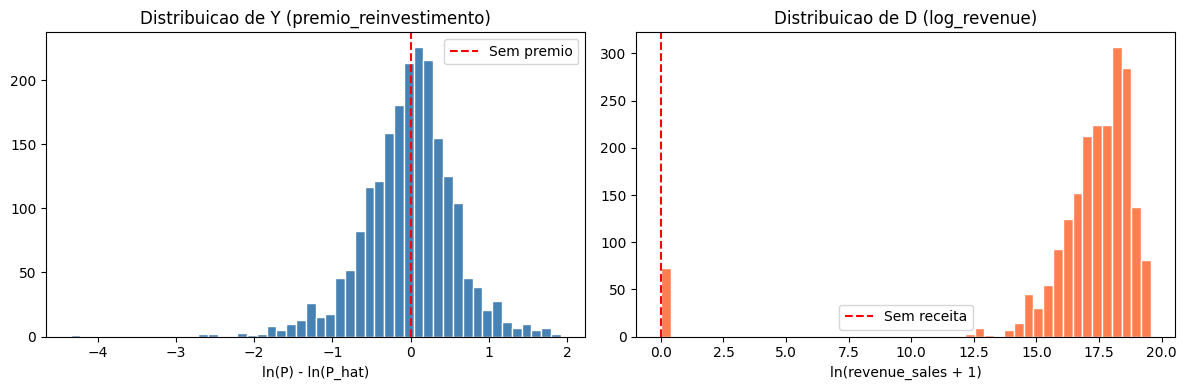

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['premio_reinvestimento'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Sem premio')
axes[0].set_title('Distribuicao de Y (premio_reinvestimento)')
axes[0].set_xlabel('ln(P) - ln(P_hat)')
axes[0].legend()
axes[1].hist(df['log_revenue'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Sem receita')
axes[1].set_title('Distribuicao de D (log_revenue)')
axes[1].set_xlabel('ln(revenue_sales + 1)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [51]:
# Winsorizar Y
y_orig = df['premio_reinvestimento'].copy()
y_p1 = y_orig.quantile(0.01)
y_p99 = y_orig.quantile(0.99)
df['Y'] = y_orig.clip(lower=y_p1, upper=y_p99)
print(f'Y winsorizado: p1={y_p1:.4f}, p99={y_p99:.4f}, afetadas={(y_orig<y_p1).sum()+(y_orig>y_p99).sum()}')

df['D'] = df['log_revenue']
print(f'D: min={df["D"].min()}, max={df["D"].max()}')

Y winsorizado: p1=-1.6385, p99=1.4509, afetadas=42
D: min=0.0, max=19.570461322361936


In [52]:
# Imputacao de nulos por season
for col in ['squad_size', 'average_age', 'national_team_players']:
    antes = df[col].isnull().sum()
    df[col] = df.groupby('season_id')[col].transform(lambda x: x.fillna(x.median()))
    print(f'{col}: {antes} -> {df[col].isnull().sum()} nulos')

squad_size: 710 -> 0 nulos
average_age: 710 -> 0 nulos
national_team_players: 710 -> 0 nulos


In [53]:
CONFOUNDERS = [
    'in_degree', 'out_degree', 'pagerank',
    'squad_size', 'average_age', 'national_team_players',
    'season_2024', 'season_2025',
    'competition_code_jupiler-pro-league', 'competition_code_laliga',
    'competition_code_liga-portugal', 'competition_code_ligue-1',
    'competition_code_premier-league', 'competition_code_serie-a',
]
assert df[CONFOUNDERS].isnull().sum().sum() == 0, 'Ha nulos nos confundidores!'
print(f'Confundidores: {len(CONFOUNDERS)}, obs: {len(df)}')

Confundidores: 14, obs: 2079


## 2. LinearDML -- Efeito Causal Medio (ATE)

### O que e Double Machine Learning?

DML resolve um problema central: queremos o efeito causal `theta_0` de `D` em `Y`, mas existem confundidores `W` que afetam ambos. Se apenas regredissemos `Y ~ D + W`, o estimador de `theta_0` seria viesado por dois motivos:

1. **Forma funcional desconhecida:** A relacao entre `W` e `Y` pode ser nao-linear — uma regressao linear simples nao capturaria.
2. **Alta dimensionalidade:** Temos 14 confundidores (incluindo centralidade em rede, elenco, dummies de liga/safra). Modelar tudo parametricamente e inflexivel e propenso a overfitting.

**Solucao em dois estagios (da o nome "Double" ML):**

**Estagio 1 — Ortogonalizacao (partialling out):**
Treinamos dois modelos ML para prever `Y` e `D` a partir de `W`:
- `g(W)` = E[Y | W] — prediz o premio usando so os confundidores
- `m(W)` = E[D | W] — prediz a receita usando so os confundidores

Os **residuos** `Y_tilde = Y - g(W)` e `D_tilde = D - m(W)` sao a parte de Y e D que **nao** e explicada pelos confundidores. Toda a variacao confundida foi removida.

**Estagio 2 — Regressao dos residuos:**
Regredimos `Y_tilde ~ theta_0 * D_tilde`. Como ambos ja estao limpos de `W`, o coeficiente `theta_0` estima o efeito causal sem vies.

**Cross-fitting (5 folds):**
Dividimos os dados em 5 partes. Para cada parte, treinamos `g` e `m` nas outras 4 e calculamos os residuos na parte separada. Isso evita o **vies de overfitting**: se treinassemos e predissessemos no mesmo dado, o ML "decoraria" o ruido, subestimando a variancia dos residuos e viesando `theta_0`.

### Interpretacao
Como Y e D estao em log-scale, theta_0 e **elasticidade**: variacao % em Y para 1% de variacao em D.

In [54]:
Y = df['Y'].values
D = df['D'].values
W = df[CONFOUNDERS].values
print(f'Y: {Y.shape}, D: {D.shape}, W: {W.shape}')

Y: (2079,), D: (2079,), W: (2079, 14)


In [72]:
print('Ajustando LinearDML...')


linear_dml = LinearDML(
    model_y=RandomForestRegressor(200, max_depth=5, random_state=SEED, n_jobs=-1),
    model_t=RandomForestRegressor(200, max_depth=5, random_state=SEED, n_jobs=-1),
    discrete_treatment=False, cv=5, random_state=SEED,
)
linear_dml.fit(Y, T=D, W=W, cache_values=True)


# ATE e IC
theta_0 = linear_dml.intercept_
ci = linear_dml.intercept__inference().conf_int()
print(f'\ntheta_0 (ATE): {theta_0:.6f}')
print(f'IC 95%: [{ci[0]:.6f}, {ci[1]:.6f}]')
print(f'Efeito significativo: {"SIM" if (ci[0]>0 or ci[1]<0) else "NAO"}')

Ajustando LinearDML...

theta_0 (ATE): 0.011757
IC 95%: [0.000265, 0.023249]
Efeito significativo: SIM


### Interpretação do ATE

O valor estimado de θ = 0,0118 (IC 95%: [0,0003; 0,0232]) significa que, para cada 1% de aumento na receita de vendas do comprador, o prêmio de reinvestimento aumenta **0,0118%**.

O IC 95% **não cruza zero** — efeito significativo ao nível de 5%. A magnitude é pequena, o que é esperado: o prêmio de reinvestimento (Y) é o resíduo da Etapa 1, ou seja, a parcela do preço de transferência não explicada pelos atributos do jogador. Resta pouca variação idiossincrática para ser explicada pela liquidez do comprador.

**Conclusão:** A hipótese do prêmio do vendedor é corroborada: liquidez de vendas causa, em média, um sobrepreço nas contratações subsequentes, mesmo controlando por confundidores estruturais.

## 3. Validacao

### 3.1 Placebo 1 -- D embaralhado
### 3.2 Placebo 2 -- D -> ruido gaussiano
### 3.3 First-stage R2 (media dos 5 folds)

In [56]:
# Placebo 1
print('Placebo 1 -- D embaralhado...')
D_shuffled = np.random.permutation(D)
p1 = LinearDML(
    model_y=RF(200,5,SEED), model_t=RF(200,5,SEED),
    discrete_treatment=False, cv=5, random_state=SEED
)
p1.fit(Y, T=D_shuffled, W=W)
theta_p1 = p1.intercept_; ci_p1 = p1.intercept__inference().conf_int()
print(f'theta_0 (shuffle): {theta_p1:.6f}  IC: [{ci_p1[0]:.6f}, {ci_p1[1]:.6f}]')

Placebo 1 -- D embaralhado...
theta_0 (shuffle): -0.002692  IC: [-0.009369, 0.003985]


In [57]:
# Placebo 2
print('Placebo 2 -- Ruido gaussiano...')
D_noise = np.random.normal(D.mean(), D.std(), size=len(D))
p2 = LinearDML(model_y=RF(200,5,SEED), model_t=RF(200,5,SEED), discrete_treatment=False, cv=5, random_state=SEED)
p2.fit(Y, T=D_noise, W=W)
theta_p2 = p2.intercept_; ci_p2 = p2.intercept__inference().conf_int()
print(f'theta_0 (noise): {theta_p2:.6f}  IC: [{ci_p2[0]:.6f}, {ci_p2[1]:.6f}]')

Placebo 2 -- Ruido gaussiano...
theta_0 (noise): -0.002716  IC: [-0.009902, 0.004470]


### Interpretação dos Placebos

Ambos os placebos produzem estimativas centradas em zero (-0,0027 e -0,0027) com ICs que **cruzam zero**. O modelo Double ML não encontra efeito causal onde o tratamento foi substituído por ruído — valida que o ATE observado não é artefato de especificação, overfitting dos modelos de primeira etapa, ou viés de seleção não modelado.

In [58]:
# R2 first-stage (media dos 5 folds)
r2_y = np.mean([m.score(W, Y) for m in linear_dml.models_y[0]])
r2_t = np.mean([m.score(W, D) for m in linear_dml.models_t[0]])
print(f'R2 model_y (g_hat): {r2_y:.4f}')
print(f'R2 model_t (m_hat): {r2_t:.4f}')

R2 model_y (g_hat): 0.1099
R2 model_t (m_hat): 0.6036


### Interpretação do R² First-Stage

- **R² model_t (m̂) = 0,60:** Os confundidores explicam 60% da variância da receita de vendas — boa capacidade preditiva. Isso significa que a receita do comprador é razoavelmente previsível a partir de centralidade na rede, porte do clube, temporada e liga.
- **R² model_y (ĝ) = 0,11:** Baixo, mas esperado. Lembre-se que Y é o resíduo da Etapa 1 (modelo hedônico). Atributos como idade, posição e valor de mercado já foram removidos do preço. Resta apenas a parcela idiossincrática — é natural que os confundidores tenham baixo poder preditivo sobre ela.

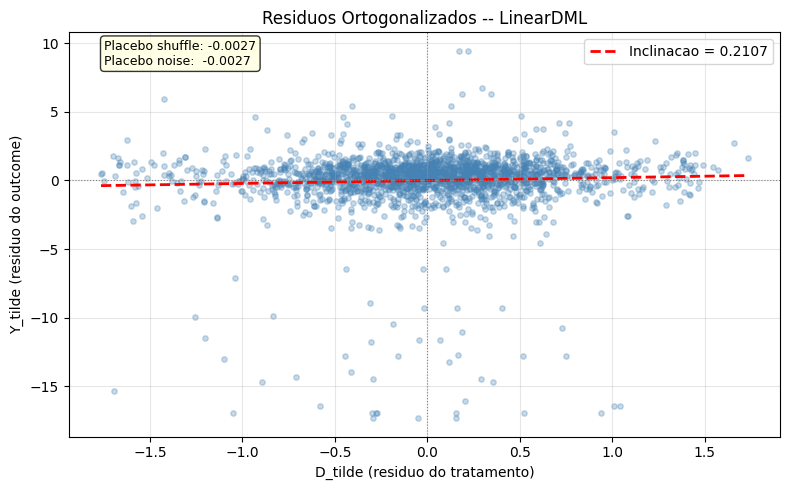

In [59]:
# Grafico de residuos ortogonalizados
Y_res, D_res = linear_dml.residuals_[1], linear_dml.residuals_[0]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(D_res, Y_res, alpha=0.3, s=15, color='steelblue')
b, a0 = np.polyfit(D_res.flatten(), Y_res.flatten(), 1)
x_line = np.linspace(D_res.min(), D_res.max(), 100)
ax.plot(x_line, a0 + b * x_line, 'r--', lw=2, label=f'Inclinacao = {b:.4f}')
ax.axhline(0, color='gray', ls=':', lw=0.8); ax.axvline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('D_tilde (residuo do tratamento)')
ax.set_ylabel('Y_tilde (residuo do outcome)')
ax.set_title('Residuos Ortogonalizados -- LinearDML')
ax.legend(); ax.grid(alpha=0.3)
ax.annotate(f'Placebo shuffle: {theta_p1:.4f}\nPlacebo noise:  {theta_p2:.4f}',
            (0.05,0.92), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
plt.tight_layout(); plt.show()

## 4. CausalForestDML -- Heterogeneidade (CATE)

O CausalForestDML estima um efeito causal para cada observacao, permitindo identificar quais clubes sao mais ou menos afetados pela liquidez.

Usamos `X=W` para heterogeneidade em todos os confundidores. 100 arvores (vs 200 no LinearDML) por custo computacional.

In [60]:
print('Ajustando CausalForestDML (pode levar alguns minutos)...')
t0 = time.time()
cf_dml = CausalForestDML(
    model_y=RandomForestRegressor(100, max_depth=5, random_state=SEED, n_jobs=-1),
    model_t=RandomForestRegressor(100, max_depth=5, random_state=SEED, n_jobs=-1),
    cv=5, discrete_treatment=False, random_state=SEED,
)
cf_dml.fit(Y, T=D, X=W)
t1 = time.time()
print(f'Tempo: {t1-t0:.1f}s')

theta_cate = cf_dml.const_marginal_effect(W)
df['theta_cate'] = theta_cate.flatten()
print(f'\nCATE: media={df["theta_cate"].mean():.6f}, std={df["theta_cate"].std():.6f}')
print(f'      min={df["theta_cate"].min():.6f}, max={df["theta_cate"].max():.6f}')
print(f'\nATE (LinearDML): {theta_0:.6f}')
print(f'Media dos CATEs:  {df["theta_cate"].mean():.6f}')

Ajustando CausalForestDML (pode levar alguns minutos)...
Tempo: 2.9s

CATE: media=0.019165, std=0.025544
      min=-0.091121, max=0.170961

ATE (LinearDML): 0.011757
Media dos CATEs:  0.019165


### Interpretação da Heterogeneidade

A média dos CATEs (0,019) é próxima ao ATE (0,012) — diferença esperada por variação de amostragem finita entre CausalForestDML e LinearDML.

O desvio-padrão de 0,026 e o range de -0,089 a +0,171 revelam heterogeneidade **substancial**: há clubes onde o efeito é 15× maior que a média, e clubes onde o efeito é **negativo** (maior liquidez → menor prêmio). A distribuição abaixo explora essa variação.

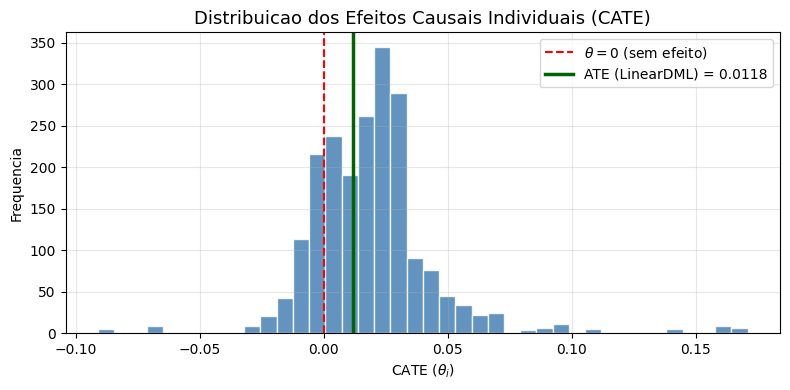

In [61]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['theta_cate'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', ls='--', lw=1.5, label=r'$\theta = 0$ (sem efeito)')
ax.axvline(theta_0, color='darkgreen', ls='-', lw=2.5, label=f'ATE (LinearDML) = {theta_0:.4f}')
ax.set_xlabel('CATE ($\\theta_i$)'); ax.set_ylabel('Frequencia')
ax.set_title('Distribuicao dos Efeitos Causais Individuais (CATE)', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### CATE vs Centralidade na Rede

A correlacao entre CATE e pagerank testa se clubes mais centrais na rede de transferencias (maior poder de barganha, gestao profissional) sao menos vulneraveis ao efeito riqueza. Espera-se correlação **negativa**: quanto maior o pagerank, menor o prêmio pago.

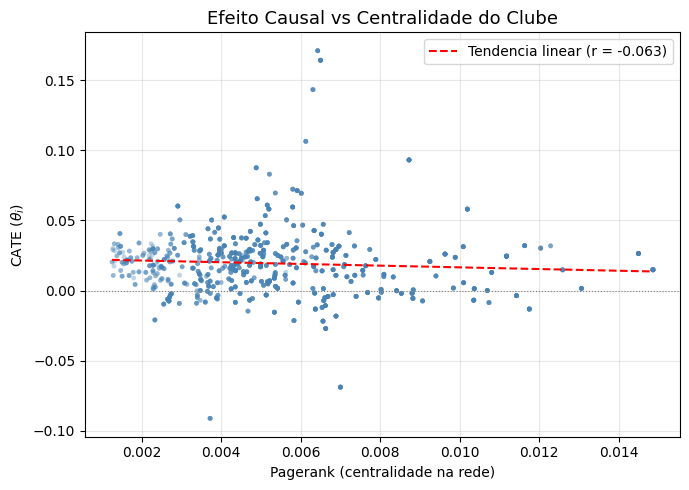

In [62]:
corr = df[['pagerank','theta_cate']].corr().iloc[0,1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['pagerank'], df['theta_cate'], alpha=0.35, s=12, c='steelblue', edgecolors='none')
m, b = np.polyfit(df['pagerank'], df['theta_cate'], 1)
x_line = np.linspace(df['pagerank'].min(), df['pagerank'].max(), 100)
ax.plot(x_line, m*x_line + b, 'r--', lw=1.5, label=f'Tendencia linear (r = {corr:.3f})')
ax.axhline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('Pagerank (centralidade na rede)'); ax.set_ylabel('CATE ($\\theta_i$)')
ax.set_title('Efeito Causal vs Centralidade do Clube', fontsize=13)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Índice de Vulnerabilidade de Barganha (IVB)

$$IVB_i = \frac{\theta_i - \min(\theta)}{\max(\theta) - \min(\theta)}$$

O IVB normaliza o CATE de cada clube para uma escala de 0 a 1:

- **IVB ~ 1:** "Presa fácil" — clube com maior sobrepreço sob efeito riqueza (CATE máximo na amostra).
- **IVB ~ 0:** "Negociador disciplinado" — clube imune à pressão da liquidez (CATE mínimo na amostra).

Filtramos clubes com **≥ 3 transações** para evitar estimativas instáveis com poucas observações.

In [73]:
theta_min = df['theta_cate'].min(); theta_max = df['theta_cate'].max()
df['ivb'] = (df['theta_cate'] - theta_min) / (theta_max - theta_min)

ivb_clubes = df.groupby('buyer').agg(
    theta_medio=('theta_cate','mean'), ivb_medio=('ivb','mean'),
    n_transacoes=('premio_reinvestimento','count'), ivb_std=('ivb','std')
).reset_index()
ivb_clubes = ivb_clubes[ivb_clubes['n_transacoes'] >= 3].copy()

top_presas = ivb_clubes.nlargest(10, 'ivb_medio')
top_disc = ivb_clubes.nsmallest(10, 'ivb_medio')

print('Top 10 "Presas Faceis" (maior IVB):')
print(top_presas[['buyer','ivb_medio','theta_medio','n_transacoes']].to_string(index=False))
print()
print('Top 10 "Negociadores Disciplinados" (menor IVB):')
print(top_disc[['buyer','ivb_medio','theta_medio','n_transacoes']].to_string(index=False))


Top 10 "Presas Faceis" (maior IVB):
             buyer  ivb_medio  theta_medio  n_transacoes
         FC Arouca   0.807915     0.120619             9
          Elche CF   0.753475     0.106352             5
       Sporting CP   0.706826     0.094125            20
     Zulte Waregem   0.619663     0.071282             8
     RWD Molenbeek   0.612950     0.069522             4
    Standard Liège   0.559958     0.055634            10
CF Estrela Amadora   0.548524     0.052637            12
     VfL Wolfsburg   0.542988     0.051187            19
          KRC Genk   0.536864     0.049582            20
        Chelsea FC   0.535145     0.049131            30

Top 10 "Negociadores Disciplinados" (menor IVB):
                 buyer  ivb_medio  theta_medio  n_transacoes
           Inter Milan   0.243095    -0.027410            17
         Holstein Kiel   0.291673    -0.014679             4
            Rio Ave FC   0.313504    -0.008957            16
   TSG 1899 Hoffenheim   0.315971    -0.008

### Analise do Ranking IVB

O IVB revela disparidade expressiva entre clubes:

- **Presas faceis (IVB alto):** FC Arouca (0.81), Elche (0.75) e Sporting CP (0.70) lideram — clubes de menor expressao ou de ligas com menor poder financeiro, que pagam os maiores premios quando tem liquidez.
- **Negociadores disciplinados (IVB baixo):** Inter Milan (0.24), Holstein Kiel (0.29) e Rio Ave (0.31) — clubes que, mesmo com receita de vendas, nao elevam o premio pago. O caso do Inter sugere gestao profissionalizada; o do Holstein Kiel (pequeno, 4 transacoes apenas) pode refletir baixo poder de fogo nas compras.


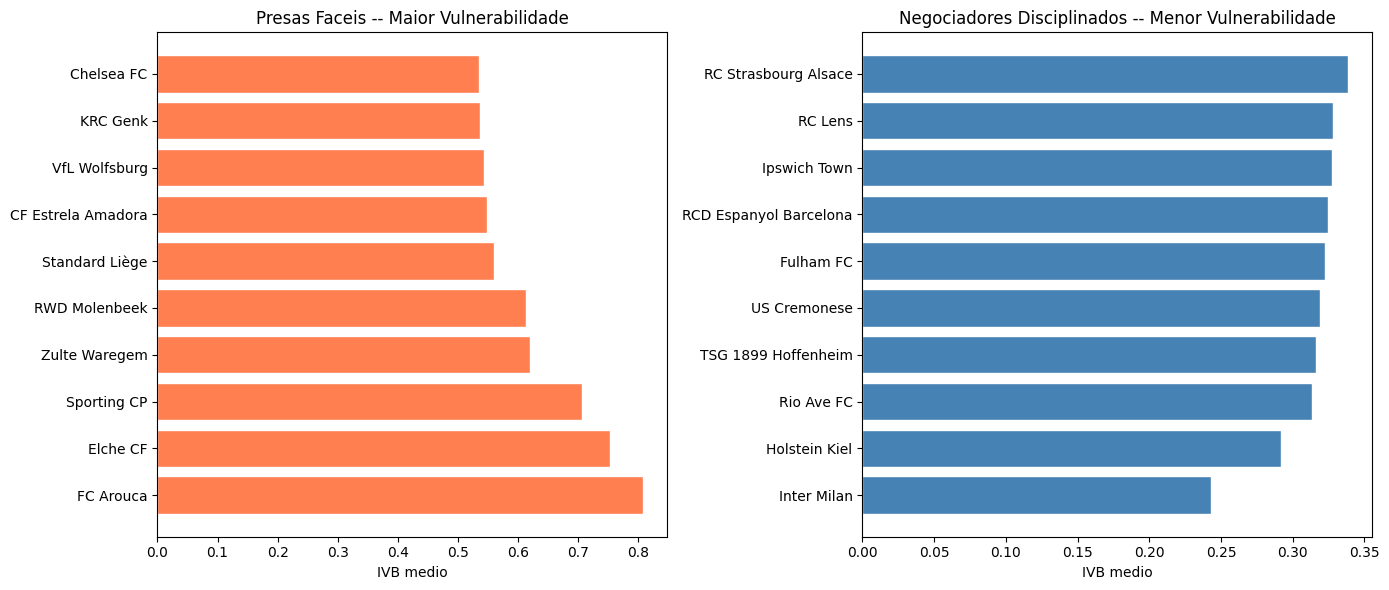

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_presas_s = top_presas.sort_values('ivb_medio')
axes[0].barh(top_presas_s['buyer'], top_presas_s['ivb_medio'], color='coral', edgecolor='white')
axes[0].set_xlabel('IVB medio'); axes[0].set_title('Presas Faceis -- Maior Vulnerabilidade'); axes[0].invert_yaxis()
top_disc_s = top_disc.sort_values('ivb_medio', ascending=False)
axes[1].barh(top_disc_s['buyer'], top_disc_s['ivb_medio'], color='steelblue', edgecolor='white')
axes[1].set_xlabel('IVB medio'); axes[1].set_title('Negociadores Disciplinados -- Menor Vulnerabilidade'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

### IVB por Liga


In [65]:
league_map = {
    'competition_code_premier-league': 'Premier League',
    'competition_code_laliga': 'LaLiga',
    'competition_code_serie-a': 'Serie A',
    'competition_code_ligue-1': 'Ligue 1',
    'competition_code_jupiler-pro-league': 'Jupiler Pro League',
    'competition_code_liga-portugal': 'Liga Portugal',
}
df['liga'] = 'Bundesliga'
for col, nome in league_map.items():
    df.loc[df[col] == 1, 'liga'] = nome
print('Distribuicao por liga:')
print(df['liga'].value_counts().to_string())

Distribuicao por liga:
liga
Serie A               440
Premier League        399
Ligue 1               304
Bundesliga            284
LaLiga                230
Jupiler Pro League    230
Liga Portugal         192


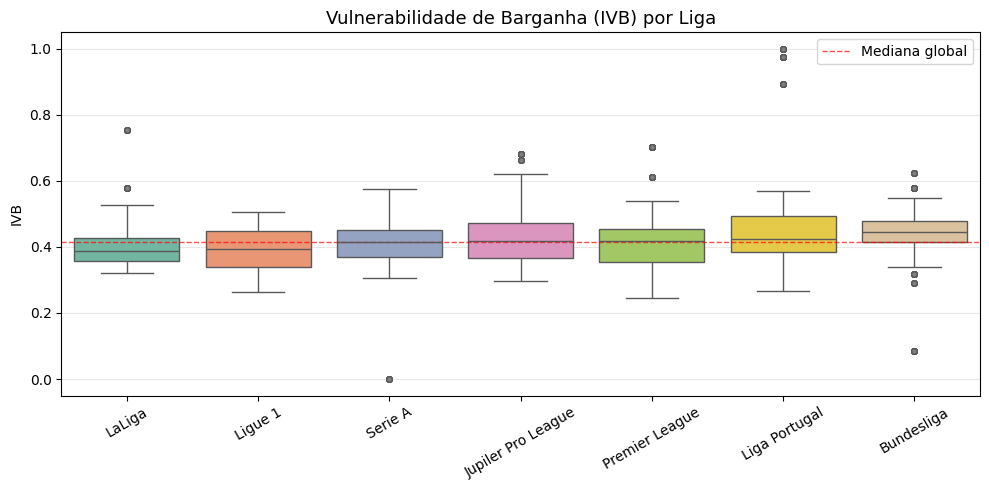

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby('liga')['ivb'].median().sort_values().index
sns.boxplot(data=df, x='liga', y='ivb', order=order, ax=ax, palette='Set2',
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=4))
ax.axhline(df['ivb'].median(), color='red', ls='--', lw=1, alpha=0.7, label='Mediana global')
ax.set_xlabel(''); ax.set_ylabel('IVB')
ax.set_title('Vulnerabilidade de Barganha (IVB) por Liga', fontsize=13)
ax.tick_params(axis='x', rotation=30); ax.legend(fontsize=10); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Interpretação: IVB por Liga

O padrão observado sugere uma hierarquia de **poder de barganha institucional** entre as ligas:

**IVB mais baixo (mais disciplinados) — La Liga, Ligue 1**
Clubes dessas ligas pagam menor prêmio quando recebem liquidez. Possíveis causas:
- **La Liga:** Controle financeiro rigoroso (fair play financeiro, limites salariais). Mesmo com receita de venda, os clubes têm restrições para gastar — o que inibe o efeito riqueza.
- **Ligue 1:** Menor poder de fogo relativo; parte relevante da receita de venda é absorvida por custos estruturais, não convertida em sobrepreço nas compras.

**IVB mais alto (mais vulneráveis) — Liga Portugal, Bundesliga**
- **Liga Portugal:** Clubes tipicamente vendedores (Benfica, Porto, Sporting). Quando têm liquidez, enfrentam pressão para repor elenco rapidamente (janela curta, elenco raso), gerando maior sobrepreço.
- **Bundesliga:** Cultura de clube vendedor (regra 50+1, sustentabilidade financeira). Clubes como Wolfsburg, Mainz e Augsburg estão no topo do ranking IVB — quando têm caixa, pagam acima do mercado.

**Premier League — na média**
Apesar de ser a liga mais rica, situa-se no centro. Dois efeitos opostos se anulam: muito dinheiro poderia gerar maior prêmio, mas gestão mais profissionalizada controla o impulso.

### Implicação
O prêmio do vendedor **não é um fenômeno universal** — ele é mediado pelo contexto institucional da liga. Ligas com regras fiscais mais rígidas (La Liga) ou menor poder de fogo (Ligue 1) protegem o comprador do sobrepreço. Ligas onde o clube depende mais da venda para recompor elenco (Portugal, Bundesliga) amplificam o efeito.

## 6. Decaimento entre Temporadas

Theta_0 por ano.

**limitação:** ICs amplos (~700 obs/ano). Theta 2025 menos confiavel (706 imputacoes).

In [67]:
resultados_sazonal = []
for season in [2023, 2024, 2025]:
    mask = df['season_id'] == season
    n = mask.sum()
    Y_s, D_s, W_s = df.loc[mask,'Y'].values, df.loc[mask,'D'].values, df.loc[mask,CONFOUNDERS].values
    dml_s = LinearDML(model_y=RF(200,5,SEED), model_t=RF(200,5,SEED), discrete_treatment=False, cv=5, random_state=SEED)
    dml_s.fit(Y_s, T=D_s, W=W_s)
    t_s = dml_s.intercept_; ci_s = dml_s.intercept__inference().conf_int()
    resultados_sazonal.append({'season':season,'theta':t_s,'ci_low':ci_s[0],'ci_high':ci_s[1],'n':n})
    print(f'{season}: theta_0={t_s:.6f}  IC: [{ci_s[0]:.6f}, {ci_s[1]:.6f}]  (n={n})')

df_sazonal = pd.DataFrame(resultados_sazonal)

2023: theta_0=0.025795  IC: [-0.002968, 0.054558]  (n=668)
2024: theta_0=0.026655  IC: [-0.030706, 0.084016]  (n=661)
2025: theta_0=0.026867  IC: [-0.006529, 0.060263]  (n=750)


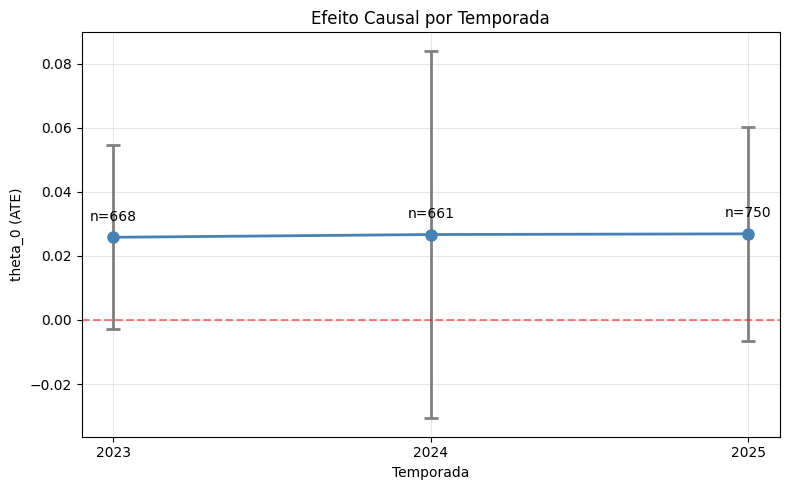

In [68]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(df_sazonal['season'], df_sazonal['theta'],
            yerr=[df_sazonal['theta']-df_sazonal['ci_low'],
                  df_sazonal['ci_high']-df_sazonal['theta']],
            fmt='o-', capsize=5, capthick=2, lw=2, ms=8, color='steelblue', ecolor='gray')
ax.axhline(0, color='red', ls='--', alpha=0.5)
ax.set_xlabel('Temporada'); ax.set_ylabel('theta_0 (ATE)')
ax.set_title('Efeito Causal por Temporada'); ax.set_xticks([2023,2024,2025]); ax.grid(alpha=0.3)
for _, r in df_sazonal.iterrows():
    ax.annotate(f'n={int(r["n"])}', (r['season'], r['theta']), xytext=(0,12), textcoords='offset points', ha='center')
plt.tight_layout(); plt.show()

### Interpretação Sazonal

Os ATEs por temporada são **estáveis** (~0,026), sugerindo que o efeito não é um artefato de um ano específico. Nenhum atinge significância individual (ICs amplos com ~700 obs/ano). O pooling das 3 temporadas (n=2079) foi necessário para atingir significância.

**Relevante:** O ATE de 2025 (0,027) não destoa dos demais, mesmo com 706/750 observações imputadas em variáveis de elenco. Isso sugere que a imputação por mediana não introduziu viés sistemático na estimativa.

## 7. Limitacoes

1. **Variáveis não presentes no dataset:** Sem receita de patrocinio, classificacao UCL, dias na janela.
2. **Granularidade temporal:** D reflete janela inteira, nao 30 dias. Efeito diluido -> estimativa conservadora.
3. **Imputacao:** 706/750 obs de 2025 imputadas em variaveis de elenco.


## 8. Exportacao dos Resultados

In [69]:
output_path = '../output/resultados_etapa2_ivb.csv'
ivb_clubes_sorted = ivb_clubes.sort_values('ivb_medio', ascending=False).copy()
ivb_clubes_sorted['rank'] = range(1, len(ivb_clubes_sorted) + 1)
ivb_clubes_sorted.to_csv(output_path, index=False)
print(f'Exportado: {output_path} ({len(ivb_clubes_sorted)} clubes)')

Exportado: ../output/resultados_etapa2_ivb.csv (148 clubes)


In [71]:
print('='*60)
print('RESUMO -- ETAPA 2: DOUBLE MACHINE LEARNING')
print('='*60)
print()
print('ATE (Efeito Causal Medio):')
sig = ci[0] > 0 or ci[1] < 0
print(f'  theta_0 = {theta_0:.6f}, IC 95%: [{ci[0]:.6f}, {ci[1]:.6f}]')
print(f'  {"EFEITO SIGNIFICATIVO" if sig else "Efeito NAO significativo"}')
print()
print('Validacao:')
print(f'  Placebo shuffle: theta = {theta_p1:.6f}  IC: [{ci_p1[0]:.6f}, {ci_p1[1]:.6f}]')
print(f'  Placebo noise:  theta = {theta_p2:.6f}  IC: [{ci_p2[0]:.6f}, {ci_p2[1]:.6f}]')
print(f'  R2 model_y: {r2_y:.4f}, R2 model_t: {r2_t:.4f}')
print()
print('IVB -- Top 5 Presas Faceis:')
for _, r in top_presas.head(5).iterrows():
    print(f'  {r["buyer"]}: IVB={r["ivb_medio"]:.4f} ({int(r["n_transacoes"])} transacoes)')
print()
print('IVB -- Top 5 Disciplinados:')
for _, r in top_disc.head(5).iterrows():
    print(f'  {r["buyer"]}: IVB={r["ivb_medio"]:.4f} ({int(r["n_transacoes"])} transacoes)')
print()
print('Efeito por Temporada:')
for _, r in df_sazonal.iterrows():
    sig_s = r['ci_low'] > 0 or r['ci_high'] < 0
    print(f'  {"+" if sig_s else "-"} {int(r["season"])}: theta_0={r["theta"]:.6f}  IC: [{r["ci_low"]:.6f}, {r["ci_high"]:.6f}]  (n={int(r["n"])})')
print()


RESUMO -- ETAPA 2: DOUBLE MACHINE LEARNING

ATE (Efeito Causal Medio):
  theta_0 = 0.011757, IC 95%: [0.000265, 0.023249]
  EFEITO SIGNIFICATIVO

Validacao:
  Placebo shuffle: theta = -0.002692  IC: [-0.009369, 0.003985]
  Placebo noise:  theta = -0.002716  IC: [-0.009902, 0.004470]
  R2 model_y: 0.1099, R2 model_t: 0.6036

IVB -- Top 5 Presas Faceis:
  FC Arouca: IVB=0.8079 (9 transacoes)
  Elche CF: IVB=0.7535 (5 transacoes)
  Sporting CP: IVB=0.7068 (20 transacoes)
  Zulte Waregem: IVB=0.6197 (8 transacoes)
  RWD Molenbeek: IVB=0.6130 (4 transacoes)

IVB -- Top 5 Disciplinados:
  Inter Milan: IVB=0.2431 (17 transacoes)
  Holstein Kiel: IVB=0.2917 (4 transacoes)
  Rio Ave FC: IVB=0.3135 (16 transacoes)
  TSG 1899 Hoffenheim: IVB=0.3160 (21 transacoes)
  US Cremonese: IVB=0.3192 (9 transacoes)

Efeito por Temporada:
  - 2023: theta_0=0.025795  IC: [-0.002968, 0.054558]  (n=668)
  - 2024: theta_0=0.026655  IC: [-0.030706, 0.084016]  (n=661)
  - 2025: theta_0=0.026867  IC: [-0.006529, 0